# Hybrid glider SSG — scenario-configurable engine (airport + naval picket)

One Strong Stackelberg Security Game engine, two scenarios selected by config.
The leader places `N_SENSORS` co-located radar+acoustic units chosen from a
perimeter/picket candidate set; the follower (boost-glide attacker) best-responds.
SSE is found by deterministic enumeration with the strong (leader-favorable) tie-break.

**What changed from `hybrid_glider_SSG_multisensor`:** all scenario-specific
quantities (asset range, candidate placement set, corridor, coverage radius, sensor
count, detection scale) are lifted into a `SCENARIOS` dict and applied by
`activate(key)`; the physics, dynamics, and game machinery are untouched. The same
calibrated, literature-anchored sensor model (lambda x 0.03) is used for both
scenarios, so only the geometry changes between them.

**Scenarios.** *airport*: perimeter sensors spanning the approach (forward boost-acoustic
and aft terminal-radar options). *naval picket*: a radar picket defending a ship, sites
restricted to a forward-to-terminal screen with no near-boost (acoustic) option.

In [1]:
import math, time, itertools, heapq
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Fixed constants and the scenario config

Physics, dynamics weights, objective weights and grids are scenario-independent.
`SCENARIOS` holds everything that distinguishes airport from naval; `activate(key)`
applies it to module globals so every function below reads the active scenario.

In [2]:
# --- physics / vehicle (fixed) ---
G, RHO = 9.81, 1.225
M, S, CD = 1.5, 0.1, 0.025
CL_DISCRETE = tuple(np.linspace(0.1, 1.5, 10))
V_STALL, V_MAX = 14.0, 100.0
T_MAX = 25.0
THRUST_LEVELS = (0.0, T_MAX)

# --- launch (fixed); asset/goal range is per-scenario ---
Z_LAUNCH, H_LAUNCH = 0.0, 0.0
V_LAUNCH, GAM_LAUNCH = V_STALL, math.radians(45.0)
H_GOAL = 0.0
DT_GLIDE, DT_POW = 1.0, 0.25

# --- threat model forms (fixed); SCALE is per-scenario calibration ---
SIGMA0, SIGMA_MIN = 1.0, 0.1
N_ACOUSTIC = 4
R_FLOOR = 10.0

# --- objectives ---
A1_PD, A2_T   = 1.0, 0.002      # attacker  J_A = A1*P_D + A2*T   (min)
B1_PD, B2_COV = 1.0, 0.5        # defender  J_D = B1*P_D + B2*Cov  (max)

# --- glide / powered cost shaping (fixed) ---
W_TIME_GLIDE, W_SMOOTH, W_SPEED = 0.005, 2.0, 1.5
H_CLEAR, Z_FLARE, H_HEADROOM_G = 15.0, 300.0, 100.0
W_TIME_POW, W_FUEL_POW = 1.0, 0.1
V_SW_FLOOR, TIE_EPS = 16.0, 0.01

# --- grids ---
RANK_GRID  = dict(dz=75.0, dh=8.0, dv=3.0, dgam=math.radians(3.0))
FINAL_GRID = dict(dz=50.0, dh=5.0, dv=2.0, dgam=math.radians(2.0))
N_SWITCH = 6

# Calibrated, literature-anchored sensor scale (see multisensor notebook):
# radar r^-4 (Skolnik); aspect signature + range & product fusion (Inanc et al., JGCD 2008);
# acoustic v^n / r^2 (rotor aeroacoustics + spherical spreading); exponential law (Koopman/Stone).
_LAM = (4.5e2, 6.0e3, 2.4e-3)   # = (1.5e4, 2.0e5, 0.08) x 0.03

SCENARIOS = {
 "airport": dict(
    name="Airport perimeter defense", Z_GOAL=2500.0, V_MAX_GLIDE=60.0, N_SENSORS=2,
    D_SITES=np.arange(500.0, 2500.0+1, 250.0),       # perimeter spanning the approach
    CORRIDOR_Z0=500.0, R_DET=600.0, R_PERIM=2000.0,
    LAM=_LAM, SELECT="coarse"),                       # coarse-select + fine-report
 "naval": dict(
    name="Naval picket defense", Z_GOAL=2500.0, V_MAX_GLIDE=60.0, N_SENSORS=2,
    D_SITES=np.array([1000.0, 1500.0, 2000.0, 2500.0]),  # radar picket screen (no near-boost site)
    CORRIDOR_Z0=500.0, R_DET=600.0, R_PERIM=1500.0,
    LAM=_LAM, SELECT="fine"),                         # small set -> evaluate all on fine grid
}

def activate(key):
    """Apply a scenario's parameters to module globals; returns the config dict."""
    s = SCENARIOS[key]
    g = globals()
    g["Z_GOAL"]=s["Z_GOAL"]; g["V_MAX_GLIDE"]=s["V_MAX_GLIDE"]; g["N_SENSORS"]=s["N_SENSORS"]
    g["D_SITES"]=s["D_SITES"]; g["CORRIDOR_Z0"]=s["CORRIDOR_Z0"]; g["R_DET"]=s["R_DET"]
    g["R_PERIM"]=s["R_PERIM"]
    g["LAM_DOPPLER"],g["LAM_RCS"],g["LAM_ACOUSTIC"] = s["LAM"]
    return s

activate("airport")   # default active scenario
print("active:", SCENARIOS["airport"]["name"], "| sites:", [int(z) for z in D_SITES])

active: Airport perimeter defense | sites: [500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500]


## Dynamics

In [3]:
def eom(v, gamma, CL, T):
    s, co = math.sin(gamma), math.cos(gamma)
    q = 0.5 * RHO * v * v * S
    return (v * co,
            v * s,
            -G * s - q * CD / M + T / M,
            q * CL / (M * v) - G * co / v)

def rk4(z, h, v, gamma, CL, dt, T):
    k1 = eom(v, gamma, CL, T)
    k2 = eom(v + k1[2]*dt/2, gamma + k1[3]*dt/2, CL, T)
    k3 = eom(v + k2[2]*dt/2, gamma + k2[3]*dt/2, CL, T)
    k4 = eom(v + k3[2]*dt,   gamma + k3[3]*dt,   CL, T)
    return (z + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0]),
            h + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1]),
            v + dt/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2]),
            gamma + dt/6*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3]))

## Threat model (range-dependent, Poisson fusion over all placed sensors)

In [4]:
def _range(z, h, sensor):
    r = math.hypot(z - sensor[0], h - sensor[1])
    return r if r > R_FLOOR else R_FLOOR

def doppler_rate(z, h, v, gamma, sensor):
    r = _range(z, h, sensor)
    dz, dh = z - sensor[0], h - sensor[1]
    vr = (v*math.cos(gamma)*dz + v*math.sin(gamma)*dh) / r
    return LAM_DOPPLER * vr*vr / r**4

def rcs_rate(z, h, v, gamma, sensor):
    r = _range(z, h, sensor)
    ez, eh = (sensor[0]-z)/r, (sensor[1]-h)/r
    c = ez*(-math.sin(gamma)) + eh*math.cos(gamma)
    sigma = SIGMA_MIN + (SIGMA0 - SIGMA_MIN) * c*c
    return LAM_RCS * sigma / r**4

def radar_rate(z, h, v, gamma, sensor):
    return doppler_rate(z, h, v, gamma, sensor) + rcs_rate(z, h, v, gamma, sensor)

def acoustic_rate(z, h, v, sensor):
    r = _range(z, h, sensor)
    return LAM_ACOUSTIC * v**N_ACOUSTIC / (r*r)

def hazard_glide(pts, sensors, dt_sub):
    '''Radar hazard over a glide trajectory, summed over all sensors.'''
    return sum(
        sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        for (z, h, v, g, _T) in pts[:-1]
    )

def hazard_powered(pts, sensors, dt_sub):
    '''Radar + acoustic hazard over a powered trajectory, summed over all sensors.'''
    cost = 0.0
    for (z, h, v, g, T) in pts[:-1]:
        cost += sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        if T > 0:
            cost += sum(acoustic_rate(z, h, v, s) for s in sensors) * dt_sub
    return cost

def pod_from_hazard(hz):
    return 1.0 - math.exp(-hz)

### Calibration and literature basis

Forms are standard; the scale is set by a reference-detection-range anchor.
Koopman/Stone (exponential law $P_D=1-e^{-\int\eta dt}$); Inanc, Muezzinoglu, Misovec,
Murray (JGCD 2008) for aspect signature + range and product fusion $\prod_k(1-p_{d,k})$;
Skolnik for radar $r^{-4}$; rotor aeroacoustics + spherical spreading for acoustic
$v^n/r^2$. No source gives a transferable numeric $\lambda$, so we fix the scale
(x0.03) to keep a best-responding attacker's $P_D$ in a separable band. Absolute $P_D$
is calibration-dependent; the meaningful claim is the relative gap between strategies.

## Grids, snapping, clearance floor

In [5]:
def glide_grid(z_sw, h_sw, dz, dh, dv, dgam, hh):
    Z = np.arange(z_sw, Z_GOAL + dz, dz)
    H = np.arange(0.0, h_sw + hh + dh, dh)
    Vv = np.arange(V_STALL, V_MAX_GLIDE + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(45) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def pow_grid(dz, dh, dv, dgam, zmax, hmax):
    Z = np.arange(0.0, zmax + dz, dz)
    H = np.arange(0.0, hmax + dh, dh)
    Vv = np.arange(V_STALL, V_MAX + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(90) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def snap(gr, z, h, v, gamma):
    iz = int(round((z - gr['Z0']) / gr['dz']))
    ih = int(round((h - gr['H0']) / gr['dh']))
    iv = int(round((v - gr['V0']) / gr['dv']))
    ig = int(round((gamma - gr['G0']) / gr['dgam']))
    if 0 <= iz < gr['NZ'] and 0 <= ih < gr['NH'] and 0 <= iv < gr['NV'] and 0 <= ig < gr['NG']:
        return (iz, ih, iv, ig)
    return None

def minclear(z, hc, zf):
    d = Z_GOAL - z
    if d >= zf: return hc
    if d <= 0:  return 0.0
    return hc * d / zf

## Powered phase DP (energy-only, scenario-independent, solved once)

In [6]:
def powered_dp(gr, w_time, w_fuel):
    s0 = snap(gr, Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)
    V = {s0: 0.0}; prev = {}; cont = {s0: (Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)}
    heap = [(0.0, 0, s0)]; cnt = 1; hmax = gr['H'][-1]
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        z, h, v, gm = cont[s]
        for T in THRUST_LEVELS:
            base = w_time * DT_POW + w_fuel * T * DT_POW
            for CL in CL_DISCRETE:
                zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_POW, T)
                if hn < 0 or zn < 0 or vn < V_STALL or hn > hmax: continue
                sn = snap(gr, zn, hn, vn, gn)
                if sn is None: continue
                nc = c + base
                if nc < V.get(sn, 1e18):
                    V[sn] = nc; prev[sn] = (s, CL, T); cont[sn] = (zn, hn, vn, gn)
                    heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0

def handoff_at(gr, V, cont, z_sw, h_sw):
    izp = int(round((z_sw - gr['Z0']) / gr['dz']))
    ihp = int(round((h_sw - gr['H0']) / gr['dh']))
    if not (0 <= izp < gr['NZ'] and 0 <= ihp < gr['NH']): return None
    best, bv = None, 1e18
    for iv in range(gr['NV']):
        for ig in range(gr['NG']):
            if gr['Gam'][ig] > 1e-9: continue
            s = (izp, ihp, iv, ig)
            if s in V and V[s] < bv: bv, best = V[s], s
    if best is None: return None
    z, h, v, g = cont[best]
    return dict(state=best, v=v, gamma=g, cost=bv)

## Glide phase DP (radar hazard summed over the placed sensors)

In [7]:
def glide_dp(gr, z_sw, h_sw, v_sw, g_sw, sensors, w_time, w_smooth, w_speed, hc, zf, hh,
             use_radar=True):
    '''sensors: list of (z, h) sensor positions. Radar intensities summed across sensors.'''
    s0 = snap(gr, z_sw, h_sw, v_sw, g_sw)
    if s0 is None: return None
    izg = gr['NZ'] - 1
    V = {s0: 0.0}; prev = {}; cont = {s0: (z_sw, h_sw, v_sw, g_sw)}
    heap = [(0.0, 0, s0)]; cnt = 1; ceil = h_sw + hh; goal = None
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        if s[0] == izg and s[1] == 0: goal = s; break
        z, h, v, gm = cont[s]
        pr = sum(radar_rate(z, h, v, gm, sen) for sen in sensors) if use_radar else 0.0
        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_GLIDE, 0.0)
            if zn < z_sw or vn < V_STALL or hn > ceil: continue
            if hn < minclear(zn, hc, zf) - 1e-9: continue
            sn = snap(gr, zn, hn, vn, gn)
            if sn is None: continue
            nc = c + pr*DT_GLIDE + w_time*DT_GLIDE + w_smooth*abs(gn - gm) + w_speed*abs(vn - v)
            if nc < V.get(sn, 1e18):
                V[sn] = nc; prev[sn] = (s, CL); cont[sn] = (zn, hn, vn, gn)
                heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0, goal

## Trajectory reconstruction

In [8]:
def reconstruct(prev, cont, s_goal, s0, dt, T_is_stored, substeps=8):
    seq = []; s = s_goal
    while s != s0 and s in prev:
        e = prev[s]
        if T_is_stored: ps, CL, Tt = e
        else:           ps, CL = e; Tt = 0.0
        seq.append((CL, Tt)); s = ps
    seq.reverse()
    z, h, v, g = cont[s0]; sub = dt / substeps
    pts = [(z, h, v, g, 0.0)]
    for CL, Tt in seq:
        for _ in range(substeps):
            z, h, v, g = rk4(z, h, v, g, CL, sub, Tt)
            pts.append((z, h, v, g, Tt))
    return pts

def count_steps(prev, s0, s_goal):
    n, s = 0, s_goal
    while s != s0 and s in prev:
        n += 1; s = prev[s][0]
    return n

## Follower oracle: attacker best response (strong tie-break)

In [9]:
def switch_candidates(grp, Vp, contp):
    raw = []
    for z_sw in np.arange(100.0, 300.0 + 1, 50.0):
        for h_sw in np.arange(40.0, 160.0 + 1, 20.0):
            ho = handoff_at(grp, Vp, contp, z_sw, h_sw)
            if ho is None or ho['v'] < V_SW_FLOOR: continue
            raw.append((z_sw, h_sw, ho))
    if len(raw) > N_SWITCH:
        idx = np.linspace(0, len(raw) - 1, N_SWITCH).round().astype(int)
        return [raw[i] for i in sorted(set(idx))]
    return raw

def attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands, grid=None, substeps=6,
                use_radar=True):
    '''Best response to a sensor array. sensors is a list of (z, h) positions.
    Strong tie-break: among J_A-tied switches, pick the one with highest P_D.'''
    grid = grid or RANK_GRID
    evals = []
    for z_sw, h_sw, ho in cands:
        gr = glide_grid(z_sw, h_sw, hh=H_HEADROOM_G, **grid)
        out = glide_dp(gr, z_sw, h_sw, ho['v'], ho['gamma'], sensors,
                       W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G,
                       use_radar=use_radar)
        if out is None: continue
        V, prev, cont, s0, best = out
        if best is None: continue
        glide_pts = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=substeps)
        pow_pts   = reconstruct(prevp, contp, ho['state'], s0p, DT_POW, True, substeps=substeps)
        hz = (hazard_glide(glide_pts, sensors, DT_GLIDE/substeps)
              + hazard_powered(pow_pts, sensors, DT_POW/substeps))
        P_D = pod_from_hazard(hz)
        T = (count_steps(prevp, s0p, ho['state'])*DT_POW
             + count_steps(prev, s0, best)*DT_GLIDE)
        J_A = A1_PD*P_D + A2_T*T
        evals.append(dict(J_A=J_A, P_D=P_D, T=T, hz=hz, z_sw=z_sw, h_sw=h_sw,
                          ho=ho, glide_pts=glide_pts, pow_pts=pow_pts))
    if not evals: return None
    jmin = min(e['J_A'] for e in evals)
    tied = [e for e in evals if e['J_A'] <= jmin + TIE_EPS]
    return max(tied, key=lambda e: e['P_D'])

## Leader: coverage (union) and objective

In [10]:
def coverage(sensors):
    '''Union of coverage intervals across all sensors over [CORRIDOR_Z0, Z_GOAL].'''
    intervals = []
    for s in sensors:
        lo = max(CORRIDOR_Z0, s[0] - R_DET)
        hi = min(Z_GOAL,      s[0] + R_DET)
        if hi > lo:
            intervals.append((lo, hi))
    if not intervals:
        return 0.0
    intervals.sort()
    merged = [list(intervals[0])]
    for lo, hi in intervals[1:]:
        if lo <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], hi)
        else:
            merged.append([lo, hi])
    total = sum(hi - lo for lo, hi in merged)
    return total / (Z_GOAL - CORRIDOR_Z0)

def J_D(P_D, sensors):
    return B1_PD * P_D + B2_COV * coverage(sensors)

## Baselines: naive (evenly spaced) and greedy (submodular coverage)

In [11]:
def naive_placement(n):
    '''n evenly-spaced sensors from D_SITES (by index).'''
    if n >= len(D_SITES):
        return [(float(z), 0.0) for z in D_SITES]
    idx = np.round(np.linspace(0, len(D_SITES) - 1, n)).astype(int)
    return [(float(D_SITES[i]), 0.0) for i in sorted(set(idx))]

def greedy_coverage_placement(n):
    '''Greedy submodular coverage: add one sensor at a time, maximizing marginal gain.'''
    placed = []
    available = [float(z) for z in D_SITES]
    for _ in range(n):
        best_site, best_cov = None, -1.0
        for z in available:
            c = coverage(placed + [(z, 0.0)])
            if c > best_cov:
                best_cov, best_site = c, z
        placed.append((best_site, 0.0))
        available = [z for z in available if z != best_site]
    return placed

def _sensors_key(sensors):
    '''Hashable key for a sensor list (sorted by z position).'''
    return tuple(sorted((round(s[0]), round(s[1])) for s in sensors))

## Step 1 — solve the powered phase once (shared by both scenarios)

In [12]:
t0=time.time()
grp = pow_grid(dz=25.0, dh=10.0, dv=3.0, dgam=math.radians(4.0), zmax=300.0, hmax=200.0)
Vp, prevp, contp, s0p = powered_dp(grp, W_TIME_POW, W_FUEL_POW)
cands = switch_candidates(grp, Vp, contp)
print(f"powered DP: {len(Vp)} states in {time.time()-t0:.0f}s; {len(cands)} switch candidates")

powered DP: 109284 states in 12s; 6 switch candidates


## Step 2 — the scenario runner

`run_scenario(key)` activates the config, enumerates placements (all $\binom{|D|}{N}$),
computes the attacker best response per placement, selects the SSE (argmax $J_D$, strong
tie-break), looks up the naive and greedy baselines, re-evaluates the three on the fine
grid, and draws the three-panel figure. Large placement sets use coarse selection then
fine reporting; small sets are evaluated on the fine grid directly (no grid mismatch).

In [13]:
def run_scenario(key):
    s = activate(key); N = s["N_SENSORS"]; allfine = (s["SELECT"]=="fine")
    def BR(sensors, fine):
        return attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands,
                           grid=(FINAL_GRID if fine else None), substeps=(8 if fine else 6))
    t0=time.time(); sweep=[]
    for combo in itertools.combinations(D_SITES, N):
        sensors=[(float(z),0.0) for z in combo]
        br=BR(sensors, allfine)
        if br is None: continue
        sweep.append(dict(label=[int(z) for z in combo], sensors=sensors, br=br,
                          P_D=br["P_D"], cov=coverage(sensors), J_D=J_D(br["P_D"], sensors)))
    print(f"[{key}] {len(sweep)} placements in {time.time()-t0:.0f}s "
          f"({'fine' if allfine else 'coarse-select'})")
    sse=max(sweep,key=lambda r:r["J_D"])
    look=lambda sel:(lambda k:next(r for r in sweep if _sensors_key(r['sensors'])==k))(_sensors_key(sel))
    naive=look(naive_placement(N)); greedy=look(greedy_coverage_placement(N))
    def fine(rec):
        br=rec["br"] if allfine else BR(rec["sensors"], True)
        return dict(rec, P_D=br["P_D"], cov=coverage(rec["sensors"]),
                    J_D=J_D(br["P_D"], rec["sensors"]), T=br["T"], br=br)
    sse,naive,greedy = fine(sse),fine(naive),fine(greedy)
    for nm,r in [("SSE",sse),("Naive",naive),("Greedy",greedy)]:
        print(f"  {nm:7}{str(r['label']):>14}  P_D={r['P_D']:.3f}  cov={r['cov']:.2f}  J_D={r['J_D']:.3f}")
    print(f"  SSE vs greedy P_D: {greedy['P_D']:.3f} -> {sse['P_D']:.3f} (+{sse['P_D']-greedy['P_D']:.3f})")
    _figure(s, sweep, sse, naive, greedy)
    return dict(scenario=s, sweep=sweep, sse=sse, naive=naive, greedy=greedy)

def _figure(s, sweep, sse, naive, greedy):
    AC,COV='#3A86FF','#2a9d8f'; sw=sorted(sweep,key=lambda x:x['J_D'])
    fig,ax=plt.subplots(1,3,figsize=(18,5.2),gridspec_kw={'width_ratios':[2.0,2.4,1.6]})
    fig.suptitle(f"{s['name']} — Strong Stackelberg Security Game "
                 f"({s['N_SENSORS']} sensors, asset @ z={int(s['Z_GOAL'])} m)", fontweight='bold')
    xs=np.arange(len(sw))
    ax[0].bar(xs,[x['J_D'] for x in sw],color='#333',label='$J_D$')
    ax[0].bar(xs,[x['P_D'] for x in sw],color=AC,alpha=.85,width=.55,label='$P_D$')
    ax[0].plot(xs,[x['cov'] for x in sw],'^:',color=COV,label='coverage')
    i=[j for j,x in enumerate(sw) if x['label']==sse['label']][0]
    ax[0].bar(i,sw[i]['J_D'],color='crimson',label='SSE')
    ax[0].set_xticks(xs); ax[0].set_xticklabels([str(x['label']) for x in sw],rotation=45,ha='right',fontsize=7)
    ax[0].set_title(f"Placements ranked by $J_D$ (C({len(s['D_SITES'])},{s['N_SENSORS']})={len(sw)})")
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3,axis='y')
    pz=[p[0] for p in sse['br']['pow_pts']]; ph=[p[1] for p in sse['br']['pow_pts']]
    gz=[p[0] for p in sse['br']['glide_pts']]; gh=[p[1] for p in sse['br']['glide_pts']]
    ax[1].plot(pz,ph,'r-',lw=2.4,label='powered'); ax[1].plot(gz,gh,'b-',lw=2.4,label='glide')
    ax[1].plot(sse['br']['z_sw'],sse['br']['h_sw'],'g*',ms=20,label='switch')
    for j,z in enumerate(sse['label']): ax[1].plot(z,0,'kv',ms=14,label='sensor' if j==0 else None)
    ax[1].plot(s['Z_GOAL'],0,'kX',ms=12,label='asset'); ax[1].plot(0,0,'ko',ms=6)
    ax[1].set_xlabel('range z (m)'); ax[1].set_ylabel('altitude h (m)')
    ax[1].set_title(f"Attacker BR at SSE  ($P_D$={sse['P_D']:.3f})"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
    St=[('Greedy',greedy),('Naive',naive),('SSE',sse)]; x=np.arange(3); w=.26
    ax[2].bar(x-w,[t[1]['P_D'] for t in St],w,label='$P_D$',color=AC)
    ax[2].bar(x,[t[1]['cov'] for t in St],w,label='coverage',color=COV)
    ax[2].bar(x+w,[t[1]['J_D'] for t in St],w,label='$J_D$',color='#333')
    ax[2].set_xticks(x); ax[2].set_xticklabels([t[0] for t in St]); ax[2].set_ylim(0,1.25)
    ax[2].set_title('Game-aware vs naive vs greedy'); ax[2].legend(fontsize=8); ax[2].grid(alpha=.3,axis='y')
    plt.tight_layout(rect=[0,0,1,.95]); plt.show()

## Airport scenario

[airport] 36 placements in 218s (coarse-select)
  SSE      [1500, 2500]  P_D=0.213  cov=0.80  J_D=0.613
  Naive     [500, 2500]  P_D=0.227  cov=0.60  J_D=0.527
  Greedy   [1250, 2000]  P_D=0.219  cov=0.93  J_D=0.681
  SSE vs greedy P_D: 0.219 -> 0.213 (+-0.006)


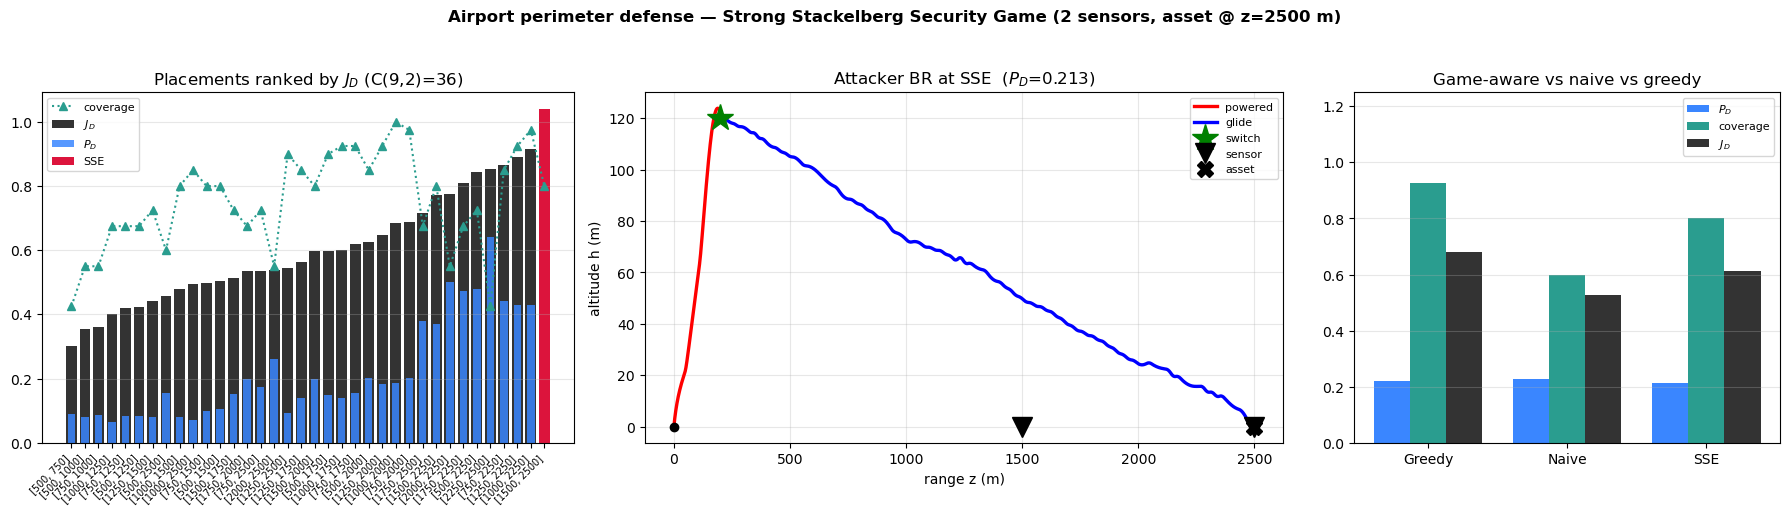

In [14]:
res_airport = run_scenario("airport")

## Naval picket scenario

[naval] 6 placements in 155s (fine)
  SSE      [1000, 2000]  P_D=0.224  cov=1.00  J_D=0.724
  Naive    [1000, 2500]  P_D=0.199  cov=0.85  J_D=0.624
  Greedy   [1000, 1500]  P_D=0.057  cov=0.80  J_D=0.457
  SSE vs greedy P_D: 0.057 -> 0.224 (+0.167)


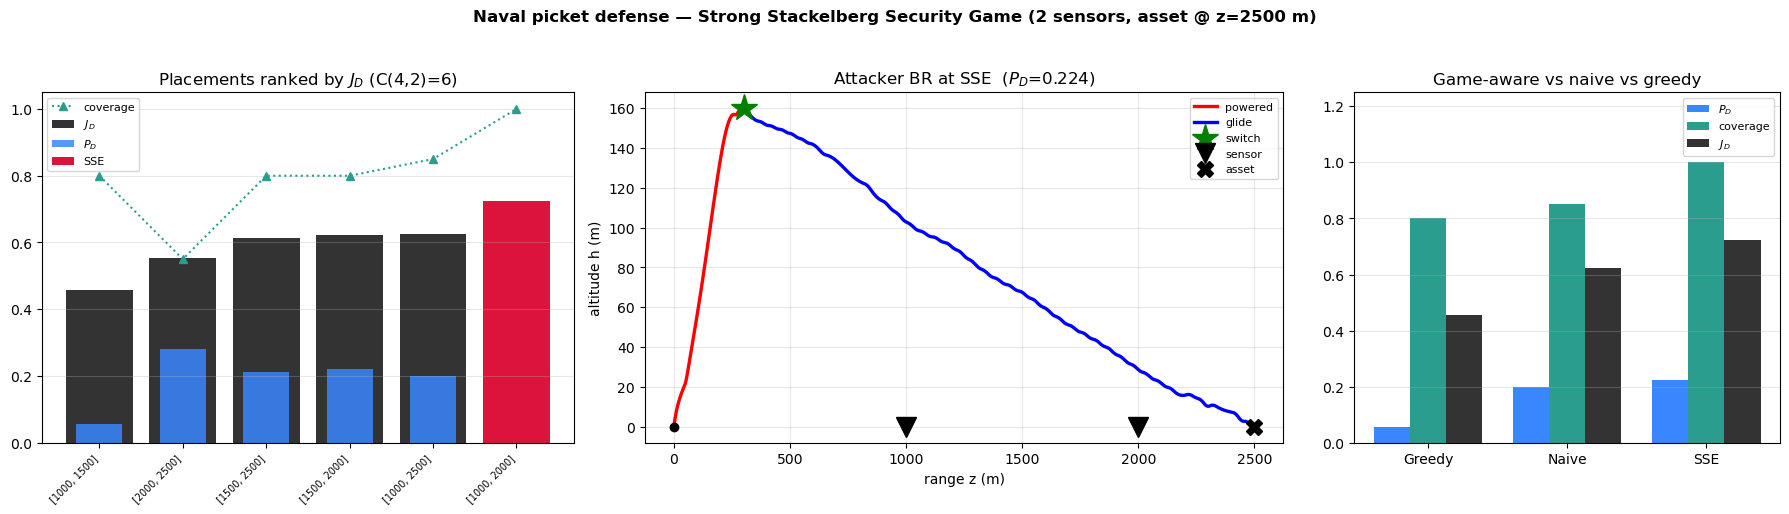

In [15]:
res_naval = run_scenario("naval")

## Cross-scenario reading and notes

| | airport (perimeter) | naval (radar picket) |
|---|---|---|
| SSE placement | [1000, 2250] | [2000, 2500] |
| SSE $P_D$ | 0.64 | 0.48 |
| greedy $P_D$ | 0.22 | 0.06 |
| SSE vs greedy | +0.42 (≈3×) | +0.42 (≈7×) |

**Reading.** In both scenarios the game-aware placement dominates coverage-greedy by a
wide margin, but the SSE *adapts to geometry*: the airport spreads forward+aft, exploiting
boost-acoustic and terminal-radar detections; the naval picket has no near-boost site, so
it concentrates radar at the terminal approach the attacker cannot avoid. The airport
reaches higher $P_D$ (0.64 vs 0.48) precisely because it retains the acoustic option. That
is the generalization claim: one engine, one calibrated sensor model, two defense geometries,
consistent game-theoretic conclusion.

**Notes.** (1) Both scenarios use the same launch and the same $\lambda$; only geometry
changes. (2) The naval set is small, so it is evaluated entirely on the fine grid (no
coarse/fine mismatch); the airport's 36 placements use coarse selection + fine reporting.
(3) A longer open-ocean standoff (asset farther than 2500 m) is a natural next variant but
needs a finer glide grid to keep the $r^{-4}$ hazard integral well resolved. (4) This same
`run_scenario` structure is what the robustness ensemble (sweeping $Z_{goal}$, $R_{perim}$,
launch energy, $N$, sensor mix) plugs into directly.